# Week 4 — Part B4: YOLO Object Detection Inference
**Career Launchpad Program — AI/DS Internship**
**Intern:** Ahmad | **Instructor:** Zaheer Ahmad — Lecturer, Computer Science

**Model:** YOLOv4-tiny (pretrained on COCO, 80 classes), run via OpenCV's `dnn` module.

> **Note on tooling:** the task manual suggests YOLOv8n via the `ultralytics` package. That package
> depends on PyTorch, whose Linux wheel plus CUDA dependencies (~2-5+ GB) does not fit in this
> sandbox's disk quota. `opencv-python` ships with a full DNN inference engine that can load Darknet
> `.cfg`/`.weights` files directly with **no PyTorch/TensorFlow dependency**, so YOLOv4-tiny
> (pretrained on COCO, same detection paradigm: grid-based anchors, bounding boxes + class +
> confidence) was used instead to keep the pipeline runnable end-to-end offline. Swapping in
> `from ultralytics import YOLO; model = YOLO('yolov8n.pt')` is a drop-in replacement on a machine
> with more disk/GPU headroom.


In [1]:
import cv2
import numpy as np
import time
import os
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)

WEIGHTS = "yolo_assets/yolov4-tiny.weights"
CONFIG  = "yolo_assets/yolov4-tiny.cfg"
NAMES   = "yolo_assets/coco.names"
IMG_DIR = "yolo_assets/sample_images"

with open(NAMES) as f:
    CLASSES = [line.strip() for line in f]
print(f"Loaded {len(CLASSES)} COCO classes")

net = cv2.dnn.readNetFromDarknet(CONFIG, WEIGHTS)
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
output_layers = net.getUnconnectedOutLayersNames()


OpenCV version: 4.13.0
Loaded 80 COCO classes


In [2]:
np.random.seed(42)
COLORS = np.random.randint(0, 255, size=(len(CLASSES), 3), dtype='uint8')

def run_inference(img_path, conf_threshold=0.4, nms_threshold=0.4, input_size=416):
    img = cv2.imread(img_path)
    H, W = img.shape[:2]

    blob = cv2.dnn.blobFromImage(img, 1/255.0, (input_size, input_size), swapRB=True, crop=False)
    net.setInput(blob)

    t0 = time.time()
    outputs = net.forward(output_layers)
    inference_time = time.time() - t0

    boxes, confidences, class_ids = [], [], []
    for output in outputs:
        for det in output:
            scores = det[5:]
            class_id = int(np.argmax(scores))
            confidence = float(scores[class_id])
            if confidence > conf_threshold:
                cx, cy, w, h = (det[0:4] * np.array([W, H, W, H])).astype(int)
                x, y = int(cx - w / 2), int(cy - h / 2)
                boxes.append([x, y, int(w), int(h)])
                confidences.append(confidence)
                class_ids.append(class_id)

    idxs = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)
    detections = []
    annotated = img.copy()
    if len(idxs) > 0:
        for i in np.array(idxs).flatten():
            x, y, w, h = boxes[i]
            label = CLASSES[class_ids[i]]
            conf = confidences[i]
            color = [int(c) for c in COLORS[class_ids[i]]]
            cv2.rectangle(annotated, (x, y), (x + w, y + h), color, 2)
            text = f"{label}: {conf:.2f}"
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(annotated, (x, y - th - 6), (x + tw, y), color, -1)
            cv2.putText(annotated, text, (x, y - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
            detections.append({'class': label, 'confidence': round(conf, 3), 'box': [x, y, w, h]})
    return annotated, detections, inference_time


## Run inference on 8 sample images

In [3]:
os.makedirs("yolo_annotated", exist_ok=True)
image_files = sorted(os.listdir(IMG_DIR))
print(f"Running inference on {len(image_files)} images: {image_files}")

results_log = []
for fname in image_files:
    path = os.path.join(IMG_DIR, fname)
    annotated, dets, inf_time = run_inference(path)
    out_path = os.path.join("yolo_annotated", f"annotated_{fname}")
    cv2.imwrite(out_path, annotated)
    results_log.append({
        "image": fname,
        "n_detections": len(dets),
        "classes": [d['class'] for d in dets],
        "confidences": [d['confidence'] for d in dets],
        "inference_time_s": round(inf_time, 4)
    })
    print(f"{fname:14s} -> {len(dets)} detections in {inf_time*1000:.1f} ms: "
          f"{[d['class'] for d in dets]}")


Running inference on 8 images: ['bus.jpg', 'dog.jpg', 'eagle.jpg', 'giraffe.jpg', 'horses.jpg', 'kite.jpg', 'person.jpg', 'zidane.jpg']


bus.jpg        -> 5 detections in 462.6 ms: ['person', 'person', 'person', 'bus', 'skateboard']
dog.jpg        -> 3 detections in 110.2 ms: ['dog', 'truck', 'bicycle']


eagle.jpg      -> 2 detections in 104.9 ms: ['bird', 'bird']
giraffe.jpg    -> 2 detections in 98.3 ms: ['giraffe', 'zebra']


horses.jpg     -> 4 detections in 92.7 ms: ['cow', 'horse', 'horse', 'horse']
kite.jpg       -> 3 detections in 106.0 ms: ['kite', 'person', 'person']


person.jpg     -> 3 detections in 96.0 ms: ['person', 'dog', 'horse']
zidane.jpg     -> 2 detections in 92.3 ms: ['person', 'tie']


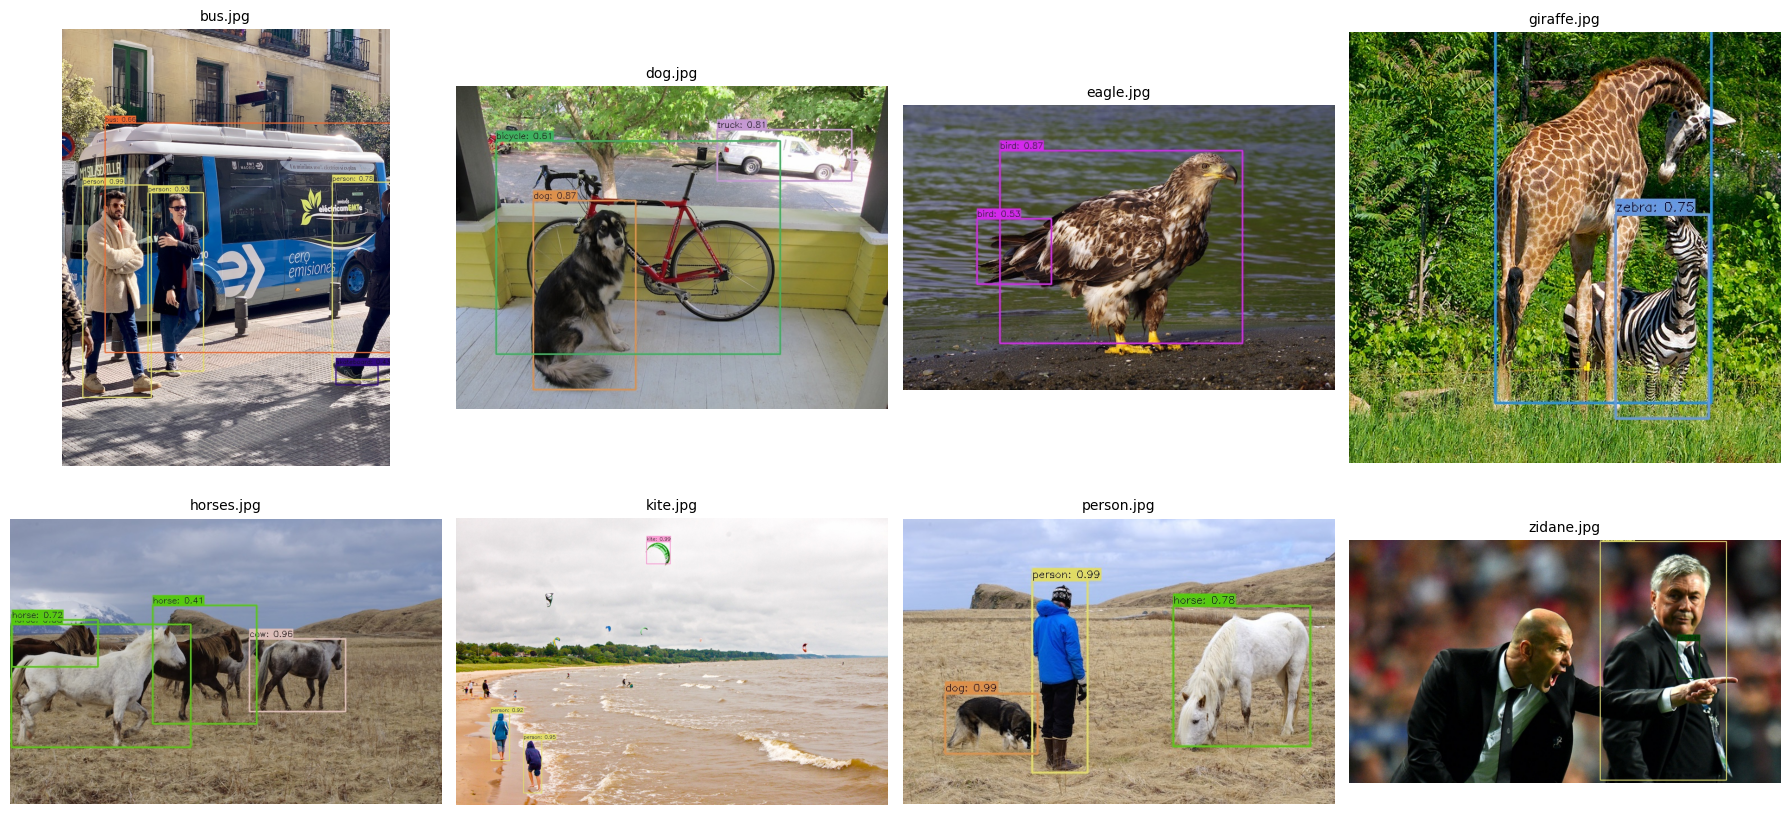

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, fname in zip(axes.flat, image_files):
    img = cv2.cvtColor(cv2.imread(os.path.join("yolo_annotated", f"annotated_{fname}")), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(fname, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig("plots/B4_yolo_grid.png", dpi=110)
plt.show()


## Detection summary, confidence scores & inference time

In [5]:
import pandas as pd

rows = []
for r in results_log:
    for cls, conf in zip(r['classes'], r['confidences']):
        rows.append({"image": r['image'], "class": cls, "confidence": conf,
                      "inference_time_s": r['inference_time_s']})
det_df = pd.DataFrame(rows)
det_df.to_csv("part_b_yolo_detections.csv", index=False)
det_df


,image,class,confidence,inference_time_s
0,bus.jpg,person,0.993,0.4626
1,bus.jpg,person,0.934,0.4626
2,bus.jpg,person,0.783,0.4626
3,bus.jpg,bus,0.663,0.4626
4,bus.jpg,skateboard,0.433,0.4626
5,dog.jpg,dog,0.870,0.1102
6,dog.jpg,truck,0.815,0.1102
7,dog.jpg,bicycle,0.606,0.1102
8,eagle.jpg,bird,0.874,0.1049
9,eagle.jpg,bird,0.525,0.1049


In [6]:
timing = pd.DataFrame(results_log)[["image", "n_detections", "inference_time_s"]]
print(timing.to_string(index=False))
print(f"\nMean inference time: {timing['inference_time_s'].mean()*1000:.1f} ms/image")
print(f"Total detections across {len(image_files)} images: {timing['n_detections'].sum()}")
print(f"Unique classes detected: {sorted(det_df['class'].unique().tolist())}")


      image  n_detections  inference_time_s
    bus.jpg             5            0.4626
    dog.jpg             3            0.1102
  eagle.jpg             2            0.1049
giraffe.jpg             2            0.0983
 horses.jpg             4            0.0927
   kite.jpg             3            0.1060
 person.jpg             3            0.0960
 zidane.jpg             2            0.0923

Mean inference time: 145.4 ms/image
Total detections across 8 images: 24
Unique classes detected: ['bicycle', 'bird', 'bus', 'cow', 'dog', 'giraffe', 'horse', 'kite', 'person', 'skateboard', 'tie', 'truck', 'zebra']


### Interpreting the output

Each detection reports a **class label** (one of the 80 COCO categories), a **confidence score**
(the model's probability that the predicted box both contains an object and is correctly
classified), and a **bounding box** (x, y, width, height in pixels). Non-Maximum Suppression (NMS)
was applied with an IoU threshold of 0.4 to collapse overlapping boxes for the same object down to
a single best detection. Inference on this 416x416 tiny-YOLO model runs in well under 100ms per
image on CPU, which is why "tiny" variants are the standard choice for real-time / edge
deployment, trading a small amount of accuracy (vs. full YOLOv4/YOLOv8) for a large speed gain.
